In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats

warnings.filterwarnings('ignore')

In [ ]:
conn = sqlite3.connect('inventory.db')
#fetching vendor summary data
df=pd.read_sql_query("select * from vendor_sales_summary",conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,0.252977,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,0.210628,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,0.246758,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,0.271399,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,0.284128,0.983556,1.396897


In [12]:
#summary statistics
df.describe().T 

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


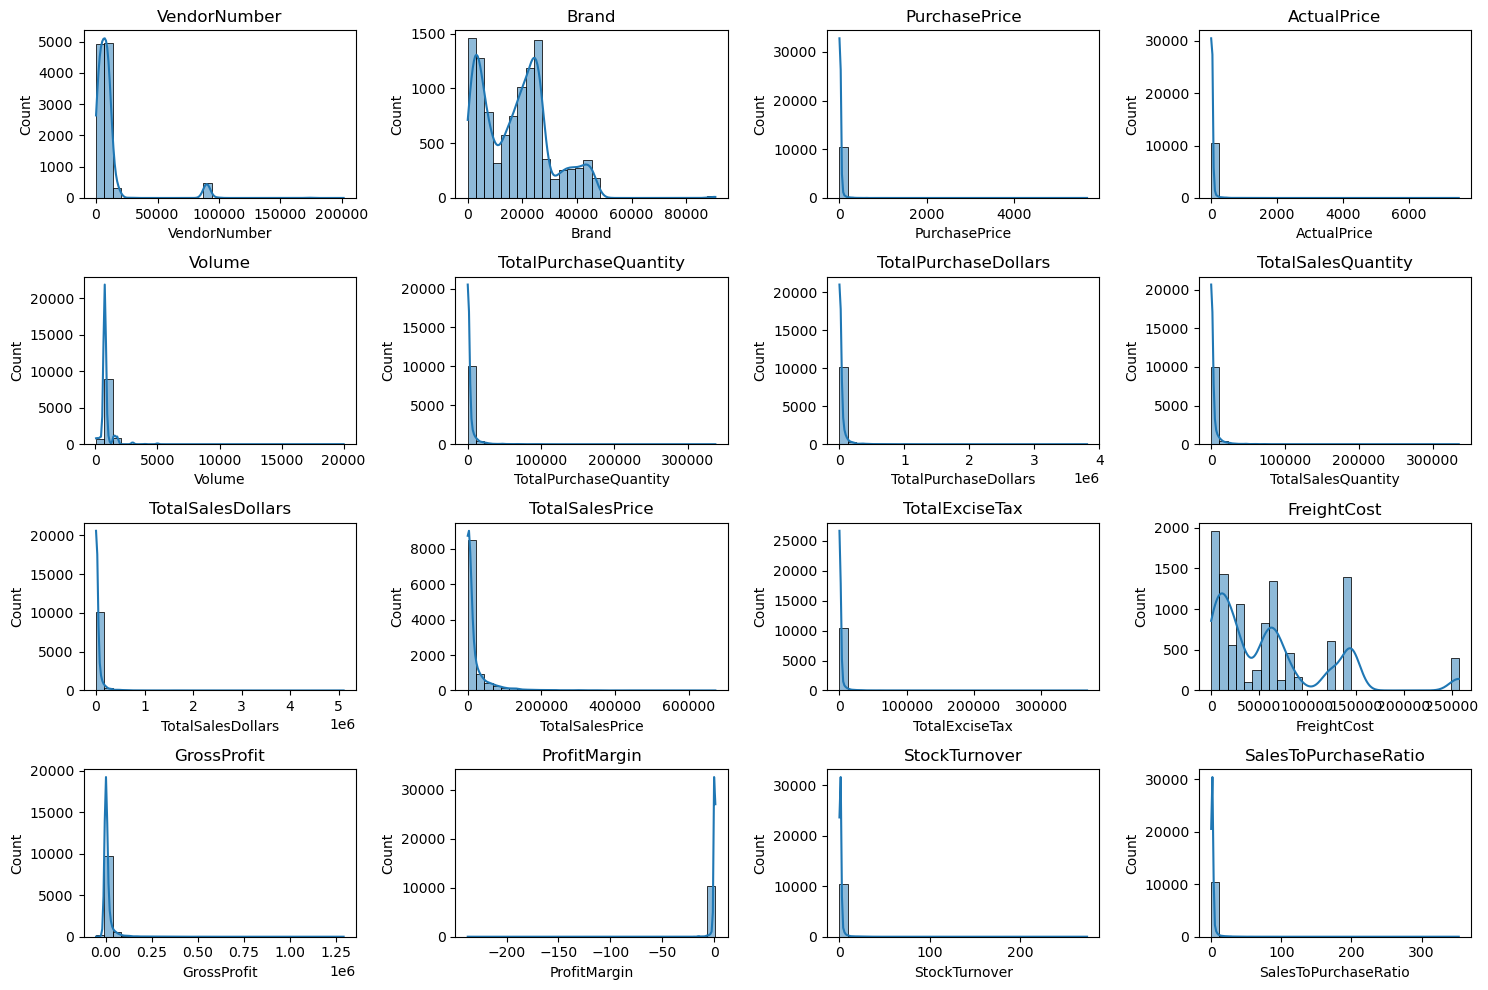

In [13]:
# Distribution Plots for Numerical Columns

numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):

    plt.subplot(4, 4, i + 1)  # Adjust grid layout as needed
    plt.title(col)

    sns.histplot(df[col], kde=True, bins=30)

plt.tight_layout()
plt.show()

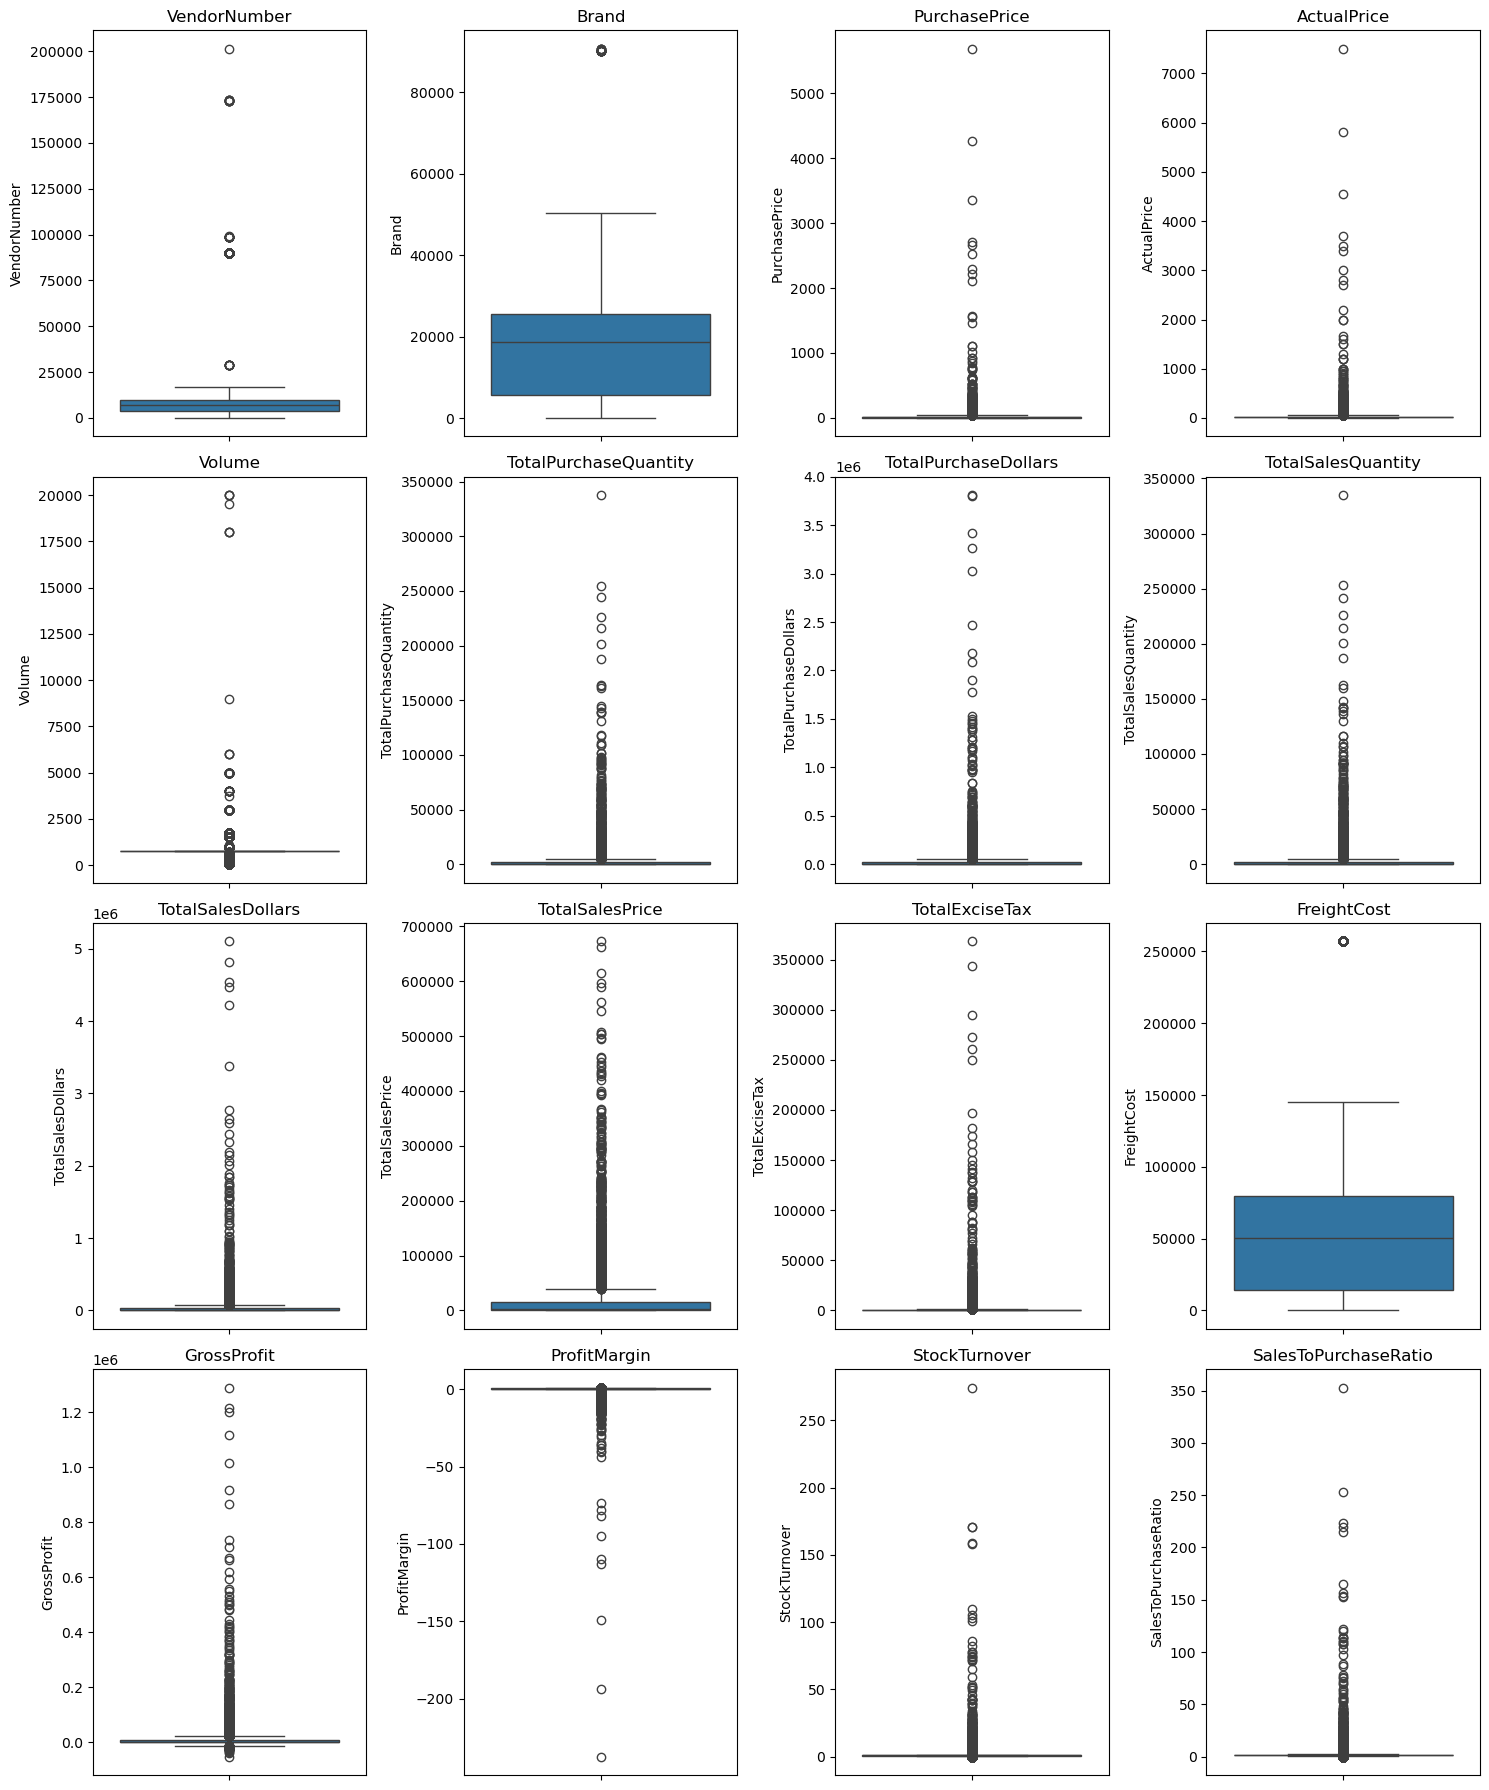

In [14]:
# Outlier Detection with Boxplots

plt.figure(figsize=(15, 18))

for i, col in enumerate(numerical_cols):

    plt.subplot(4, 4, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


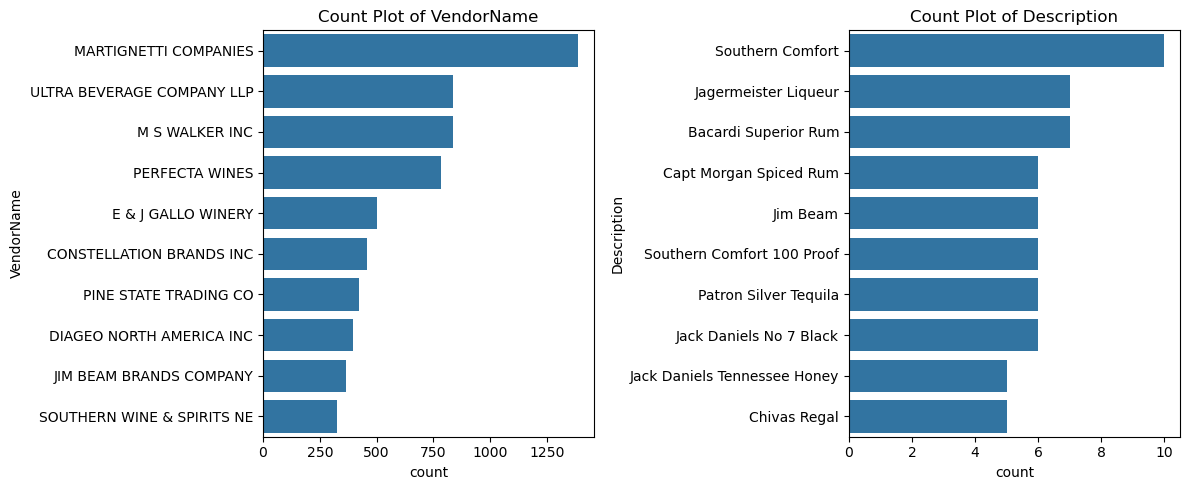

In [15]:
# Count Plots for Categorical Columns

categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12, 5))

for i, col in enumerate(categorical_cols):

    plt.subplot(1, 2, i + 1)

    top_categories = df[col].value_counts().index[:10]

    sns.countplot(
        y=df[col],
        order=top_categories
    )

    plt.title(f"Count Plot of {col}")

plt.tight_layout()
plt.show()

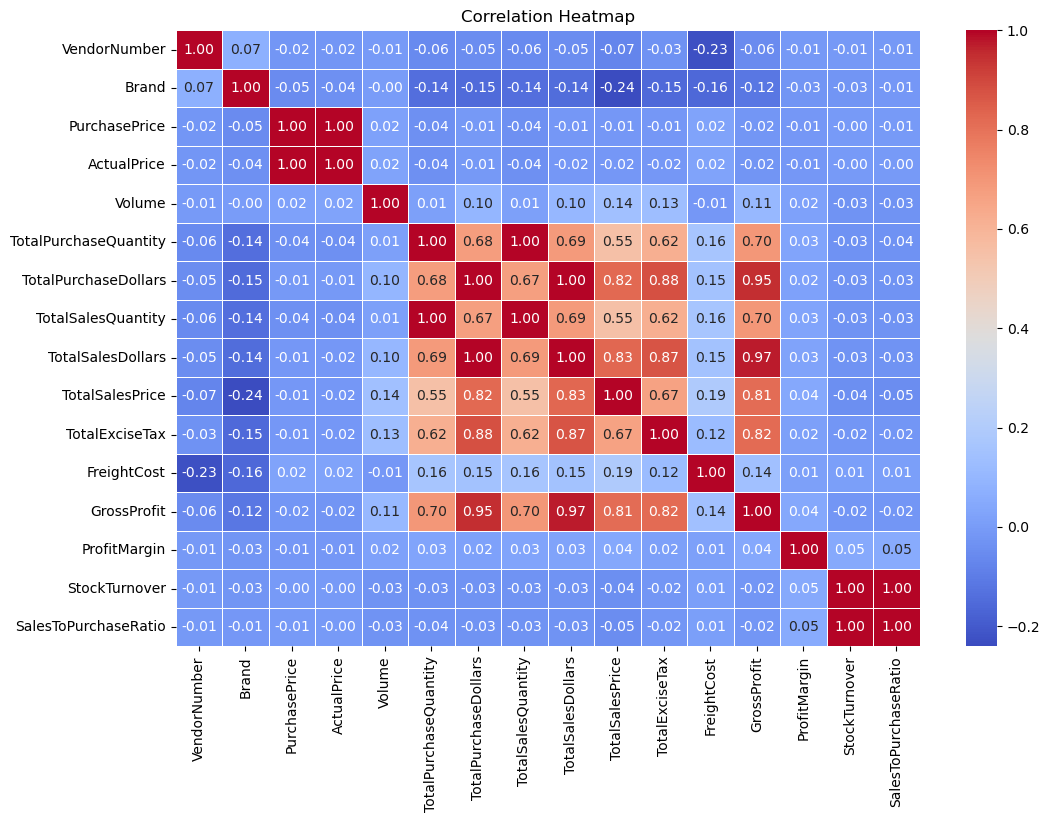

In [16]:
# Correlation Heatmap

plt.figure(figsize=(12, 8))

correlation_matrix = df[numerical_cols].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [20]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars': 'sum',
    'ProfitMargin': 'mean'
}).reset_index()

In [21]:
# thresholds
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)




In [22]:
low_sales_threshold

np.float64(286.185)

In [23]:
high_margin_threshold

np.float64(0.5619805605783905)

In [24]:
# Filter brands with low sales but high profit margins

target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]

print("Brands with Low Sales but High Profit Margins:")

display(target_brands.sort_values('TotalSalesDollars'))

Brands with Low Sales but High Profit Margins:


,Description,TotalSalesDollars,ProfitMargin
7777,Santa Rita Organic Svgn Bl,9.99,0.664665
2896,Debauchery Pnt Nr,11.58,0.659758
2537,Concannon Glen Ellen Wh Zin,15.95,0.834483
2677,Crown Royal Apple,27.86,0.898062
7818,Sauza Sprklg Wild Berry Marg,27.96,0.821531
...,...,...,...
8939,Tommasi Poggio Tufo Cab Svgn,269.73,0.747896
9229,Vigne A Porrona Rosso,272.79,0.968254
5736,Mad Dogs & Englishmen Jumil,279.80,0.976662
3980,Gifft Chardonnay,279.80,0.942459


In [29]:
brand_performance=brand_performance[brand_performance['TotalSalesDollars']<10000]

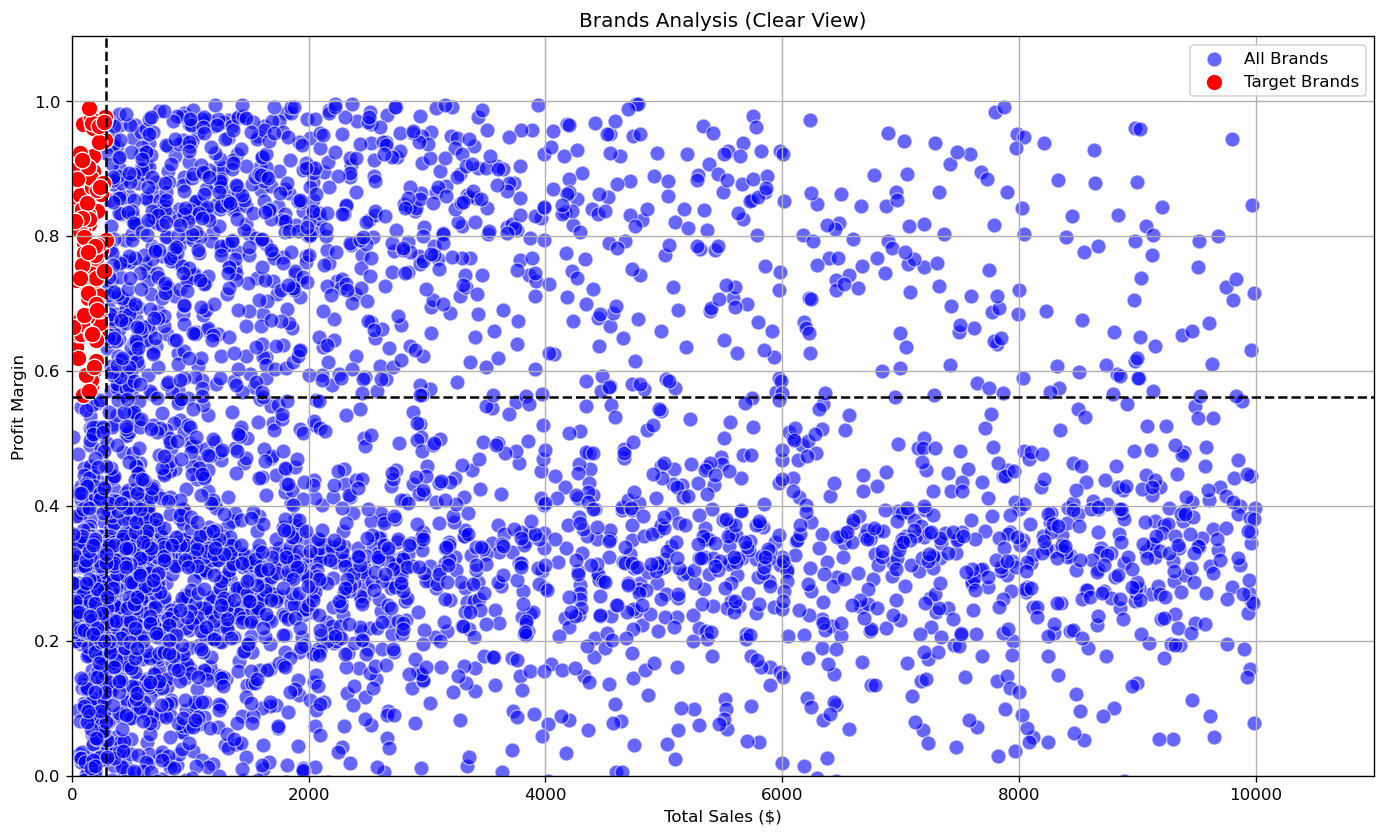

In [33]:
plt.figure(figsize=(14, 8), dpi=120)

sns.scatterplot(
    data=brand_performance,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color='blue',
    label='All Brands',
    alpha=0.6,
    s=80
)

sns.scatterplot(
    data=target_brands,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color='red',
    label='Target Brands',
    s=100
)

plt.axhline(high_margin_threshold, linestyle='--', color='black')
plt.axvline(low_sales_threshold, linestyle='--', color='black')

plt.xlim(0, brand_performance['TotalSalesDollars'].max() * 1.1)
plt.ylim(0, brand_performance['ProfitMargin'].max() * 1.1)

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin")
plt.title("Brands Analysis (Clear View)")

plt.legend()
plt.grid(True)
plt.show()

In [48]:
# Top Vendors & Brands by Sales Performance

top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)

top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)

print("Top Vendors:")
print(top_vendors)

print("\nTop Brands:")
print(top_brands)

Top Vendors:
VendorName
DIAGEO NORTH AMERICA INC      68739834.97
MARTIGNETTI COMPANIES         40960117.82
PERNOD RICARD USA             32279544.17
JIM BEAM BRANDS COMPANY       31898621.16
BACARDI USA INC               25005365.79
CONSTELLATION BRANDS INC      24467134.23
E & J GALLO WINERY            18553774.66
BROWN-FORMAN CORP             18476611.60
ULTRA BEVERAGE COMPANY LLP    17802646.10
M S WALKER INC                15436066.26
Name: TotalSalesDollars, dtype: float64

Top Brands:
Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSalesDollars, dtype: float64


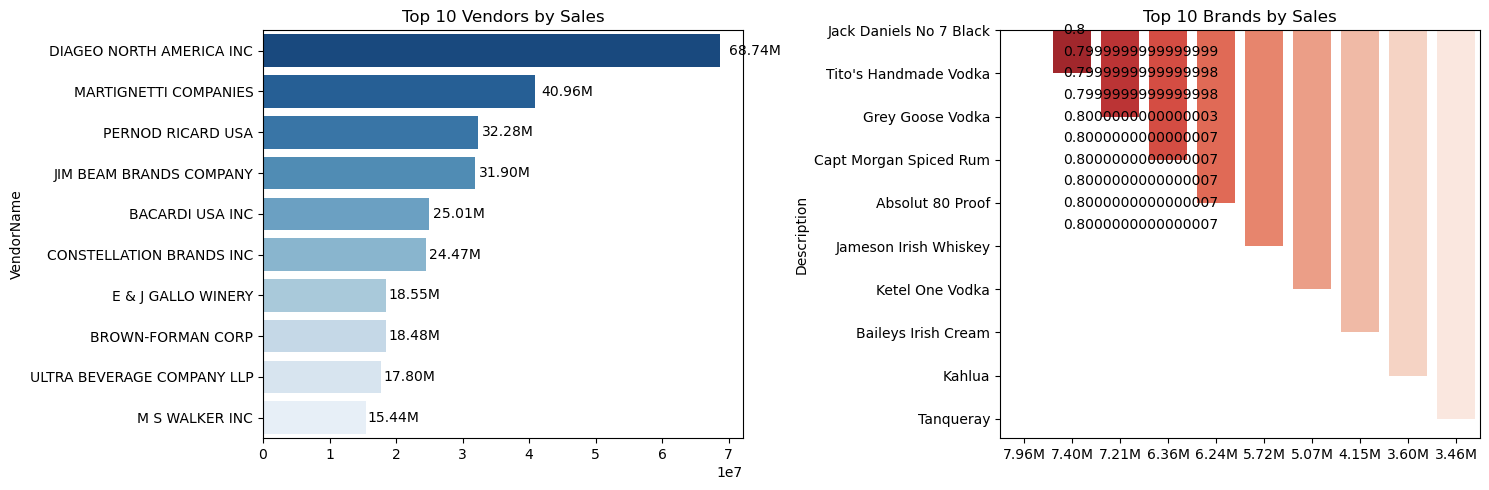

In [55]:
plt.figure(figsize=(15, 5))

# -------------------------
# Top Vendors
# -------------------------
plt.subplot(1, 2, 1)

ax1 = sns.barplot(
    y=top_vendors.index,
    x=top_vendors.values,
    palette="Blues_r"
)

plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )

# -------------------------
# Top Brands
# -------------------------
plt.subplot(1, 2, 2)

ax2 = sns.barplot(
    y=top_brands.index.astype(str),
    x=top_brands.values,
    palette="Reds_r"
)

plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )

plt.tight_layout()
plt.show()

In [64]:

#Which vendor contribute the most of the total purchase dollars?
Vendor_performance=df.groupby('VendorName').agg({
    'TotalPurchaseDollars': 'sum',
    'GrossProfit': 'sum',
    'TotalSalesDollars': 'sum'
})

In [66]:
Vendor_performance['PurchaseContributions%'] = (
    Vendor_performance['TotalPurchaseDollars'] /
    Vendor_performance['TotalPurchaseDollars'].sum()
)*


In [67]:
Vendor_performance

,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContributions%
VendorName,,,,
AAPER ALCOHOL & CHEMICAL CO,105.07,-105.07,0.00,3.264049e-07
ADAMBA IMPORTS INTL INC,76770.25,-9194.03,67576.22,2.384904e-04
ALISA CARR BEVERAGES,34951.68,78638.50,113590.18,1.085791e-04
ALTAMAR BRANDS LLC,11706.20,4000.61,15706.81,3.636587e-05
AMERICAN SPIRITS EXCHANGE,1205.16,514.81,1719.97,3.743887e-06
...,...,...,...,...
WEIN BAUER INC,43517.00,13413.23,56930.23,1.351876e-04
WESTERN SPIRITS BEVERAGE CO,361249.21,81820.99,443070.20,1.122238e-03
WILLIAM GRANT & SONS INC,5960744.35,1674483.96,7635228.31,1.851734e-02


In [68]:
round(Vendor_performance.sort_values('PurchaseContributions%',ascending = False),2)

,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContributions%
VendorName,,,,
DIAGEO NORTH AMERICA INC,50959796.85,17780038.12,68739834.97,0.16
MARTIGNETTI COMPANIES,27861690.02,13098427.80,40960117.82,0.09
JIM BEAM BRANDS COMPANY,24203151.05,7695470.11,31898621.16,0.08
PERNOD RICARD USA,24124091.56,8155452.61,32279544.17,0.07
BACARDI USA INC,17624378.72,7380987.07,25005365.79,0.05
...,...,...,...,...
FANTASY FINE WINES CORP,128.64,198.95,327.59,0.00
AAPER ALCOHOL & CHEMICAL CO,105.07,-105.07,0.00,0.00
SILVER MOUNTAIN CIDERS,77.18,265.33,342.51,0.00


In [79]:
Vendor_Performance = df.groupby('VendorName').agg({
    'TotalSalesDollars': 'sum',
    'TotalPurchaseDollars': 'sum',
    'GrossProfit': 'sum'
}).reset_index()

In [80]:
print(Vendor_Performance.head())

                    VendorName  TotalSalesDollars  TotalPurchaseDollars  \
0  AAPER ALCOHOL & CHEMICAL CO               0.00                105.07   
1      ADAMBA IMPORTS INTL INC           67576.22              76770.25   
2         ALISA CARR BEVERAGES          113590.18              34951.68   
3           ALTAMAR BRANDS LLC           15706.81              11706.20   
4    AMERICAN SPIRITS EXCHANGE            1719.97               1205.16   

   GrossProfit  
0      -105.07  
1     -9194.03  
2     78638.50  
3      4000.61  
4       514.81  


In [122]:
def convert_values(x):
    if isinstance(x, str):
        x = x.strip()
        if 'K' in x:
            return float(x.replace('K', '')) * 1000
        elif 'M' in x:
            return float(x.replace('M', '')) * 1000000
    return x

cols = ['TotalSalesDollars', 'TotalPurchaseDollars', 'GrossProfit']

# Step 1: Convert to numeric
Vendor_Performance[cols] = Vendor_Performance[cols].applymap(convert_values)
Vendor_Performance[cols] = Vendor_Performance[cols].apply(pd.to_numeric, errors='coerce')

# Step 2: Calculate contribution (already /100 format)
total_purchase = Vendor_Performance['TotalPurchaseDollars'].sum()

Vendor_Performance['PurchaseContribution'] = (
    Vendor_Performance['TotalPurchaseDollars'] / total_purchase
)

# Step 3: Top 10 vendors
top_vendors = Vendor_Performance.sort_values(
    by='TotalSalesDollars',
    ascending=False
).head(10)

# Step 4: Round (optional)
top_vendors['PurchaseContribution'] = top_vendors['PurchaseContribution'].round(4)

# Step 5: Format dollars (optional)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)

# Final output
print(top_vendors)

                     VendorName TotalSalesDollars TotalPurchaseDollars  \
28     DIAGEO NORTH AMERICA INC            68.74M               50.96M   
63        MARTIGNETTI COMPANIES            40.96M               27.86M   
74            PERNOD RICARD USA            32.28M               24.12M   
50      JIM BEAM BRANDS COMPANY            31.90M               24.20M   
8               BACARDI USA INC            25.01M               17.62M   
23     CONSTELLATION BRANDS INC            24.47M               15.57M   
33           E & J GALLO WINERY            18.55M               12.29M   
14            BROWN-FORMAN CORP            18.48M               13.53M   
114  ULTRA BEVERAGE COMPANY LLP            17.80M               13.21M   
59               M S WALKER INC            15.44M               10.94M   

    GrossProfit  PurchaseContribution%  PurchaseContribution  
28       17.78M              15.830903                0.1583  
63       13.10M               8.655366                0.086

In [123]:
top_vendors['cumulative_contribution'] = top_vendors['PurchaseContribution'].cumsum()

print(top_vendors)

                     VendorName TotalSalesDollars TotalPurchaseDollars  \
28     DIAGEO NORTH AMERICA INC            68.74M               50.96M   
63        MARTIGNETTI COMPANIES            40.96M               27.86M   
74            PERNOD RICARD USA            32.28M               24.12M   
50      JIM BEAM BRANDS COMPANY            31.90M               24.20M   
8               BACARDI USA INC            25.01M               17.62M   
23     CONSTELLATION BRANDS INC            24.47M               15.57M   
33           E & J GALLO WINERY            18.55M               12.29M   
14            BROWN-FORMAN CORP            18.48M               13.53M   
114  ULTRA BEVERAGE COMPANY LLP            17.80M               13.21M   
59               M S WALKER INC            15.44M               10.94M   

    GrossProfit  PurchaseContribution%  PurchaseContribution  \
28       17.78M              15.830903                0.1583   
63       13.10M               8.655366                0.0

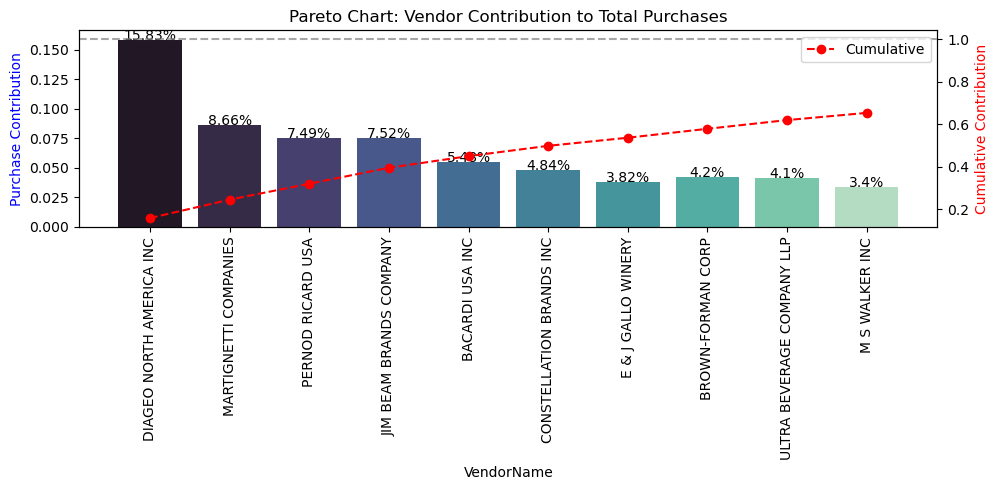

In [124]:
#Total purchase contribution of top 10 vendors is 65.69%.
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure
fig, ax1 = plt.subplots(figsize=(10, 5))

# 🔹 Bar plot (Purchase Contribution)
sns.barplot(
    x=top_vendors['VendorName'],
    y=top_vendors['PurchaseContribution'],
    palette='mako',
    ax=ax1
)

# 🔹 Add labels on bars
for i, value in enumerate(top_vendors['PurchaseContribution']):
    ax1.text(i, value, f"{round(value*100,2)}%", 
             ha='center', fontsize=10, color='black')

# 🔹 Line plot (Cumulative Contribution)
ax2 = ax1.twinx()

ax2.plot(
    top_vendors['VendorName'],
    top_vendors['cumulative_contribution'],
    color='red',
    marker='o',
    linestyle='dashed',
    label='Cumulative'
)

# 🔹 Axis labels
ax1.set_ylabel('Purchase Contribution', color='blue')
ax2.set_ylabel('Cumulative Contribution', color='red')

# 🔹 X-axis
ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)

# 🔹 Title
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

# 🔹 100% reference line
ax2.axhline(y=1, color='gray', linestyle='dashed', alpha=0.7)

# 🔹 Legend
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

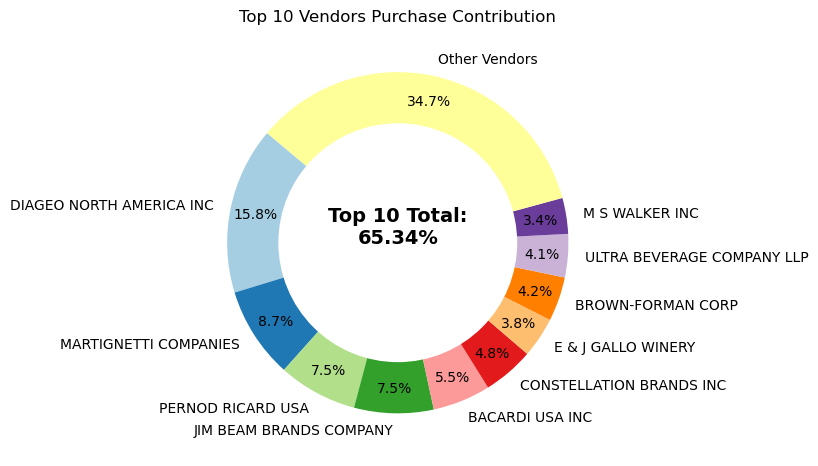

In [125]:
#import matplotlib.pyplot as plt

# Step 1: Data extract (decimal format assumed: 0–1)
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['PurchaseContribution'].values)

# Step 2: Total & remaining
total_contribution = sum(purchase_contributions)
remaining_contribution = 1 - total_contribution   # (NOT 100)

# Step 3: Add "Other Vendors"
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Step 4: Plot donut chart
fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=vendors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    colors=plt.cm.Paired.colors
)

# Step 5: Donut effect (white circle)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Step 6: Center text
plt.text(
    0, 0,
    f"Top 10 Total:\n{total_contribution*100:.2f}%",
    fontsize=14,
    fontweight='bold',
    ha='center'
)

# Step 7: Title
plt.title("Top 10 Vendors Purchase Contribution")

plt.tight_layout()
plt.show()

In [130]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity'].replace(0, None)

In [133]:
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"],q=3,labels=["small","Medium","Large"])

In [136]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean() 

,UnitPurchasePrice
OrderSize,
small,43.776954
Medium,17.894005
Large,11.308807


In [149]:
#Inventory turnover measures how quickly a vendor sells stock; a low turnover means they have excess inventory and slow-moving items.
df[df['StockTurnover'] < 1].groupby('VendorName')[['StockTurnover']].mean().sort_values(by='StockTurnover', ascending=True).head(10)

,StockTurnover
VendorName,
AAPER ALCOHOL & CHEMICAL CO,0.000000
LAUREATE IMPORTS CO,0.000000
TRUETT HURST,0.041667
"IRA GOLDMAN AND WILLIAMS, LLP",0.075000
HIGHLAND WINE MERCHANTS LLC,0.148920
UNCORKED,0.217238
MILTONS DISTRIBUTING CO,0.236111
VINEYARD BRANDS LLC,0.256241
LOYAL DOG WINERY,0.308333


In [151]:
# Unsold Inventory Value
df["UnsoldInventoryValue"] = (
    (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["PurchasePrice"]
)

# Total unsold capital
print("Total Unsold Capital:", format_dollars(df["UnsoldInventoryValue"].sum()))

Total Unsold Capital: 8.75M


In [152]:
# Aggregate capital locked per vendor
inventory_value_per_vendor = df.groupby('VendorName')[['UnsoldInventoryValue']].sum().reset_index()

# Sort vendors with highest locked capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(
    by='UnsoldInventoryValue',
    ascending=False
)

# Top 10 vendors
top10_locked = inventory_value_per_vendor.head(10)

print(top10_locked)

                     VendorName  UnsoldInventoryValue
28     DIAGEO NORTH AMERICA INC             980085.87
63        MARTIGNETTI COMPANIES             928987.31
50      JIM BEAM BRANDS COMPANY             857795.51
114  ULTRA BEVERAGE COMPANY LLP             780266.12
73               PERFECTA WINES             571806.73
74            PERNOD RICARD USA             554740.67
59               M S WALKER INC             469962.96
125    WILLIAM GRANT & SONS INC             436492.34
33           E & J GALLO WINERY             315202.46
14            BROWN-FORMAN CORP             284906.60


In [155]:
# Thresholds
top_threshold = df['TotalSalesDollars'].quantile(0.75)
low_threshold = df['TotalSalesDollars'].quantile(0.25)

# Top performing vendors
top_vendors = df[df['TotalSalesDollars'] > top_threshold]['ProfitMargin'].dropna()*100

# Low performing vendors
low_vendors = df[df['TotalSalesDollars'] < low_threshold]['ProfitMargin'].dropna()*100

In [156]:
top_vendors

0       25.297693
1       21.062810
2       24.675786
3       27.139908
4       28.412764
          ...    
5530    93.085860
5648    90.021514
5651    89.883453
5773    95.012530
5945    94.271857
Name: ProfitMargin, Length: 2673, dtype: float64

In [157]:


def confidence_interval(data, confidence=0.95):
    data = np.array(data)

    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))

    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)

    margin_of_error = t_critical * std_err

    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

In [168]:
import numpy as np

# Step 1: Force clean numeric values
top_vendors = np.array(top_vendors, dtype=float)
low_vendors = np.array(low_vendors, dtype=float)

# Step 2: Remove invalid values
top_vendors = top_vendors[np.isfinite(top_vendors)]
low_vendors = low_vendors[np.isfinite(low_vendors)]

# Step 3: Convert negative profit margin to absolute (IMPORTANT FIX)
top_vendors = np.abs(top_vendors)
low_vendors = np.abs(low_vendors)

# Step 4: Recalculate CI safely
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

# Step 5: Print clean output
print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

Top Vendors 95% CI: (30554829.33, 31404987.11), Mean: 30979908.22
Low Vendors 95% CI: (155101570.40, 224875478.87), Mean: 189988524.64


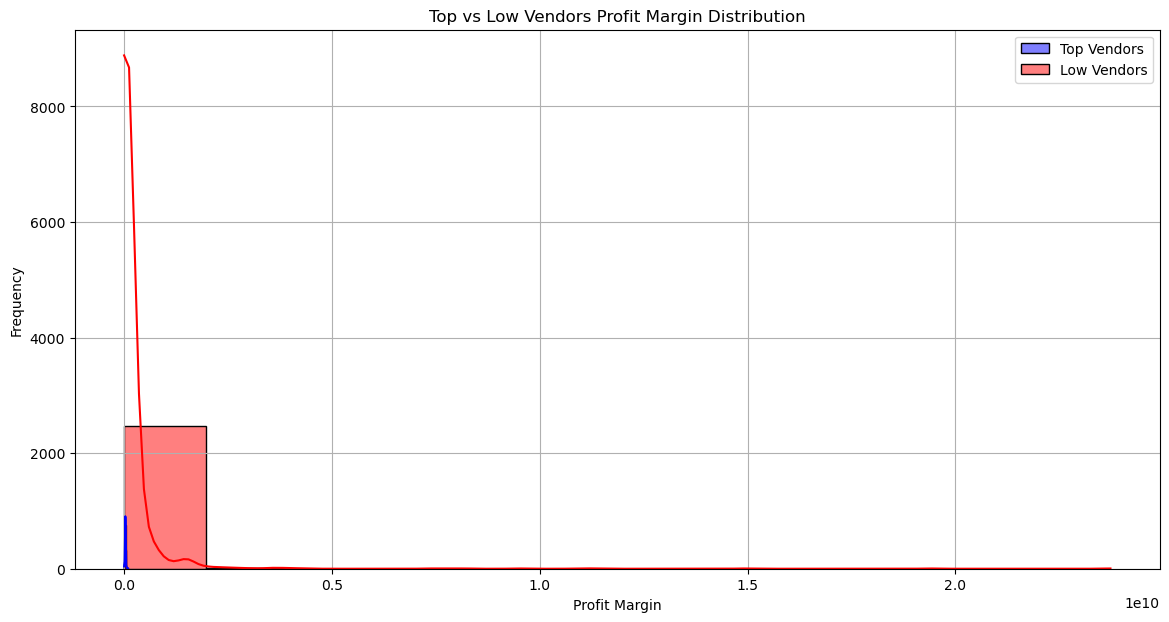

In [169]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Clean data
top_vendors = np.array(top_vendors, dtype=float)
low_vendors = np.array(low_vendors, dtype=float)

top_vendors = top_vendors[np.isfinite(top_vendors)]
low_vendors = low_vendors[np.isfinite(low_vendors)]

plt.figure(figsize=(14, 7))

# Top vendors histogram
sns.histplot(
    top_vendors,
    bins=12,
    kde=True,
    color="blue",
    alpha=0.5,
    label="Top Vendors"
)

# Low vendors histogram
sns.histplot(
    low_vendors,
    bins=12,
    kde=True,
    color="red",
    alpha=0.5,
    label="Low Vendors"
)

# Labels
plt.title("Top vs Low Vendors Profit Margin Distribution")
plt.xlabel("Profit Margin")
plt.ylabel("Frequency")

plt.legend()
plt.grid(True)

plt.show()

In [171]:
import numpy as np
import scipy.stats as stats
import pandas as pd

# Step 1: Remove NaN and infinite values
top_vendors = df[df['TotalSalesDollars'] > df['TotalSalesDollars'].quantile(0.75)]['ProfitMargin'].dropna()
low_vendors = df[df['TotalSalesDollars'] < df['TotalSalesDollars'].quantile(0.25)]['ProfitMargin'].dropna()

top_vendors = top_vendors[np.isfinite(top_vendors)]
low_vendors = low_vendors[np.isfinite(low_vendors)]

# Step 2: Check if we have enough data
if len(top_vendors) < 2 or len(low_vendors) < 2:
    print("Not enough valid data for both groups. Check your data.")
else:
    # Step 3: Perform Two-Sample T-Test
    t_stat, p_value = stats.ttest_ind(top_vendors, low_vendors, equal_var=False)
    
    # Step 4: Print results
    print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")
    
    # Step 5: Decision
    if p_value < 0.05:
        print("Reject Null Hypothesis: There is a significant difference in profit margins between top and low-performing vendors.")
    else:
        print("Fail to Reject Null Hypothesis: No significant difference in profit margins.")

T-Statistic: 9.5687, P-Value: 0.0000
Reject Null Hypothesis: There is a significant difference in profit margins between top and low-performing vendors.
